In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
dataset = pd.read_csv('/home/pavel/Загрузки/Telegram Desktop/TS(1).csv')

In [455]:
df_new = pd.read_csv('/home/pavel/Загрузки/Telegram Desktop/TS(1).csv')

In [3]:
dataset

,Time,Users
0,1/1/17 0:00,34002
1,1/1/17 1:00,37947
2,1/1/17 2:00,41517
3,1/1/17 3:00,44476
4,1/1/17 4:00,46234
...,...,...
2620,4/20/17 5:00,34833
2621,4/20/17 6:00,35932
2622,4/20/17 7:00,38418
2623,4/20/17 8:00,40238


In [4]:
dataset['Time'] = pd.to_datetime(dataset['Time'])

/tmp/ipykernel_61318/309485229.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['Time'] = pd.to_datetime(dataset['Time'])


In [5]:
dataset['year'] = dataset['Time'].dt.year
dataset['month'] = dataset['Time'].dt.month
dataset['day'] = dataset['Time'].dt.day
dataset['hour'] = dataset['Time'].dt.hour

In [6]:
dataset = dataset.drop(columns = ['Time'])

In [7]:
dataset

,Users,year,month,day,hour
0,34002,2017,1,1,0
1,37947,2017,1,1,1
2,41517,2017,1,1,2
3,44476,2017,1,1,3
4,46234,2017,1,1,4
...,...,...,...,...,...
2620,34833,2017,4,20,5
2621,35932,2017,4,20,6
2622,38418,2017,4,20,7
2623,40238,2017,4,20,8


In [143]:
day = dataset['day']
month = dataset['month']

In [162]:
week_yanuar = dataset[(day >= 1) & (day <= 7) & (month == 1)]

In [164]:
result_yanuar_week = seasonal_decompose(week_yanuar['Users'], model = 'additive', period = 24)
trend_yanuar_week = result_yanuar_week.trend
seasonal_yanuar_week = result_yanuar_week.seasonal
reisid_yanuar_week = result_yanuar_week.resid
observed_yanuar_week = result_yanuar_week.observed

<Figure size 1200x900 with 0 Axes>

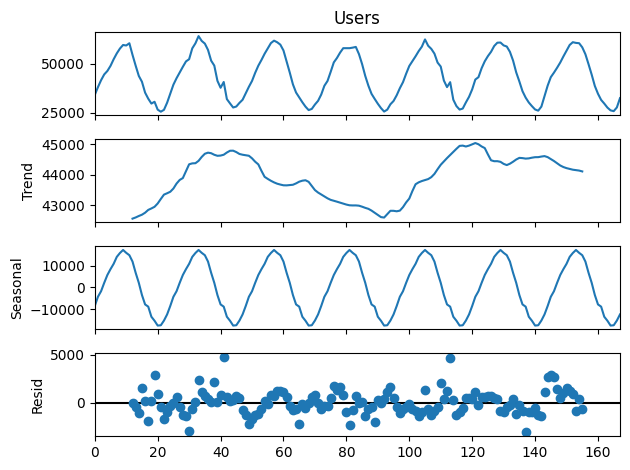

In [168]:
plt.figure(figsize = (12, 9))
result_yanuar_week.plot()
plt.show()

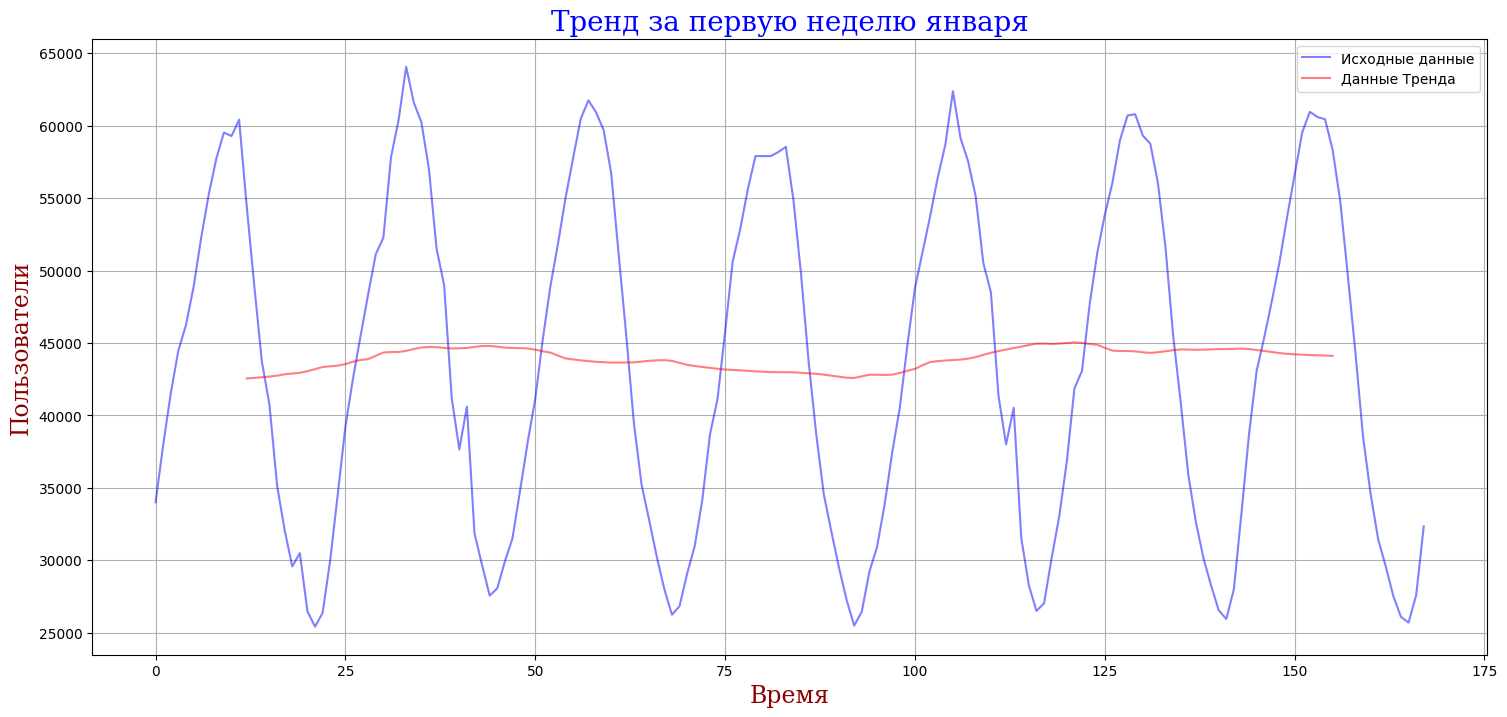

In [167]:
plt.figure(figsize = (18, 8))
plt.plot(observed_yanuar_week, 'b', alpha = 0.5, label= ('Исходные данные'))
plt.plot(trend_yanuar_week, 'r', alpha = 0.5, label = ('Данные Тренда'))
plt.title('Тренд за первую неделю января',fontdict = font1)
plt.xlabel('Время',fontdict = font2)
plt.ylabel('Пользователи', fontdict = font2)
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

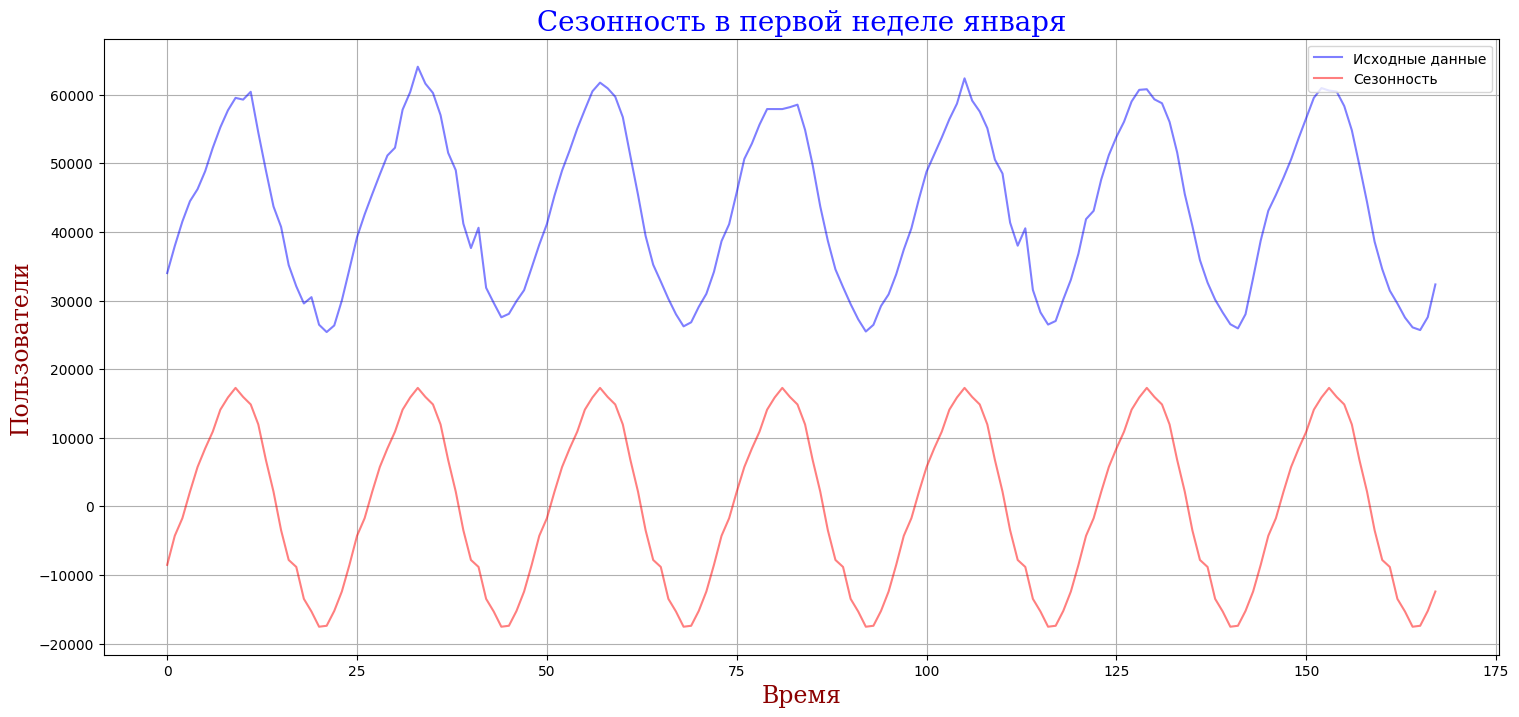

In [170]:
plt.figure(figsize = (18,8))
plt.plot(observed_yanuar_week, 'b', alpha = 0.5, label='Исходные данные')
plt.plot(seasonal_yanuar_week, 'r', alpha = 0.5, label='Сезонность')
plt.xlabel('Время',fontdict = font2)
plt.ylabel('Пользователи', fontdict = font2)
plt.title('Сезонность в первой неделе января', fontdict = font1)
plt.legend(loc = ('upper right'))
plt.grid()
plt.show()

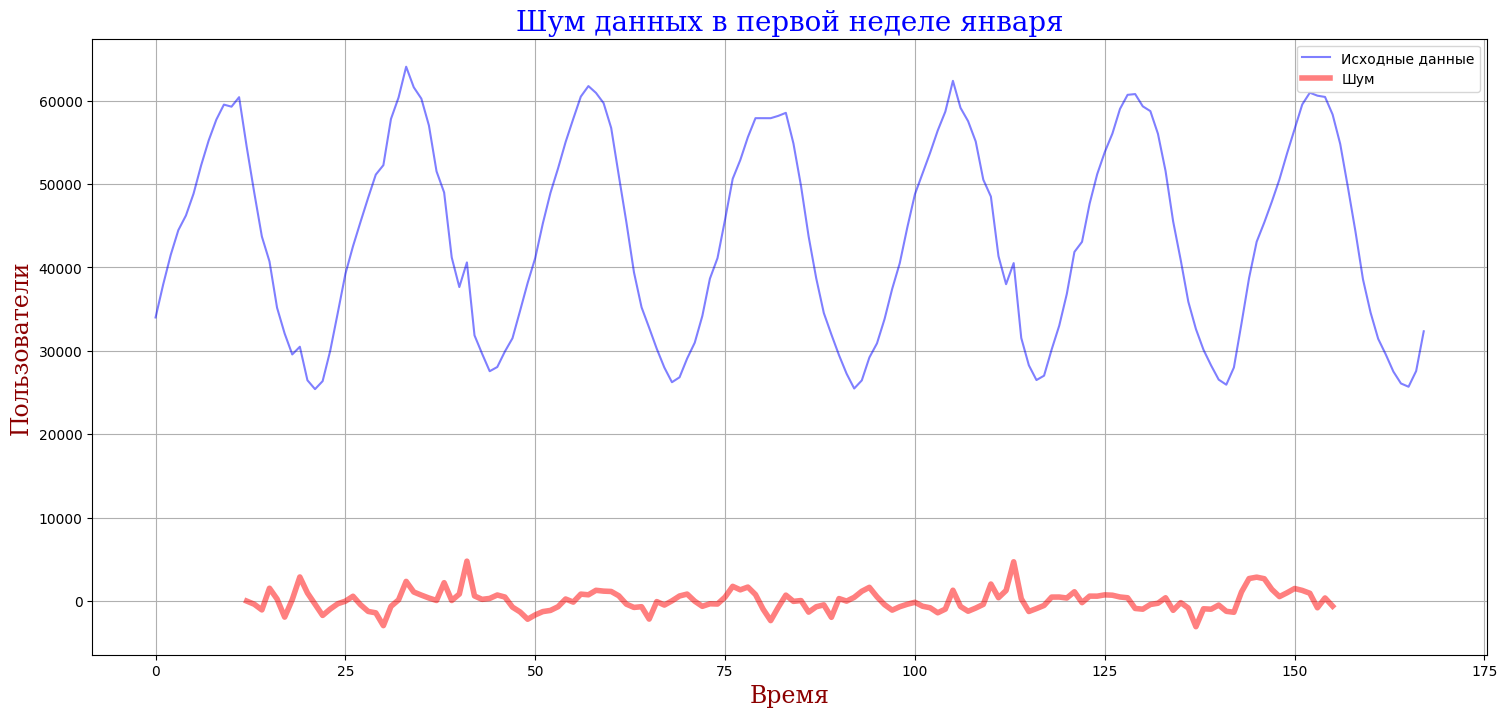

In [175]:
plt.figure(figsize = (18, 8))
plt.plot(observed_yanuar_week, 'b', alpha = 0.5, label = ('Исходные данные'))
plt.plot(reisid_yanuar_week, 'r', alpha = 0.5, linewidth = 4, label = ('Шум'))
plt.title('Шум данных в первой неделе января', fontdict = font1)
plt.xlabel('Время', fontdict = font2)
plt.ylabel('Пользователи', fontdict = font2)
plt.grid()
plt.legend(loc = 'upper right')
plt.show()

In [176]:
month_yanuar = dataset[(day >= 1) & (day <= 31) & (month == 1)]

In [177]:
result_yanuar = seasonal_decompose(month_yanuar['Users'], model = 'additive', period= 24)

In [178]:
trend_yanuar = result_yanuar.trend
seasonal_yanuar = result_yanuar.seasonal
reisid_yanuar = result_yanuar.resid
observed_yanuar = result_yanuar.observed

In [179]:
font1 = {'family':'serif','color':'blue','size':20}
font2 = {'family':'serif','color':'darkred','size':17}

<Figure size 1200x900 with 0 Axes>

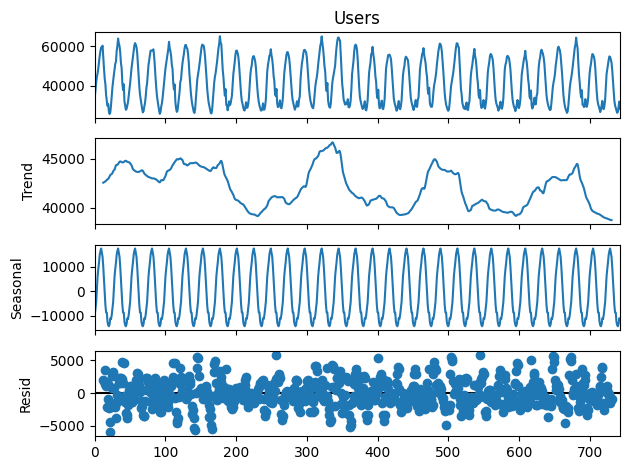

In [180]:
plt.figure(figsize = (12, 9))
result_yanuar.plot()
plt.show()

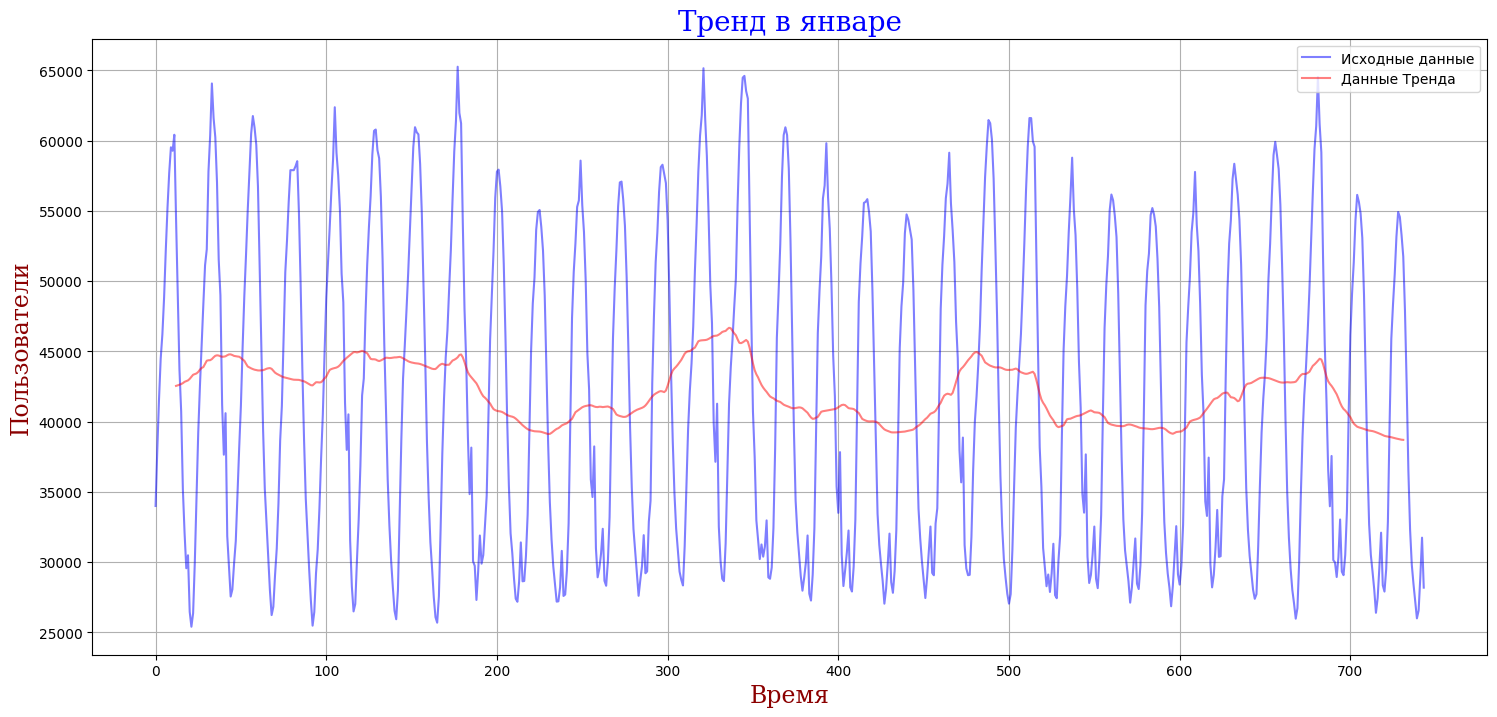

In [184]:
plt.figure(figsize = (18, 8))
plt.plot(observed_yanuar, 'b', alpha = 0.5, label= ('Исходные данные'))
plt.plot(trend_yanuar, 'r', alpha = 0.5, label = ('Данные Тренда'))
plt.title('Тренд в январе',fontdict = font1)
plt.xlabel('Время',fontdict = font2)
plt.ylabel('Пользователи', fontdict = font2)
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

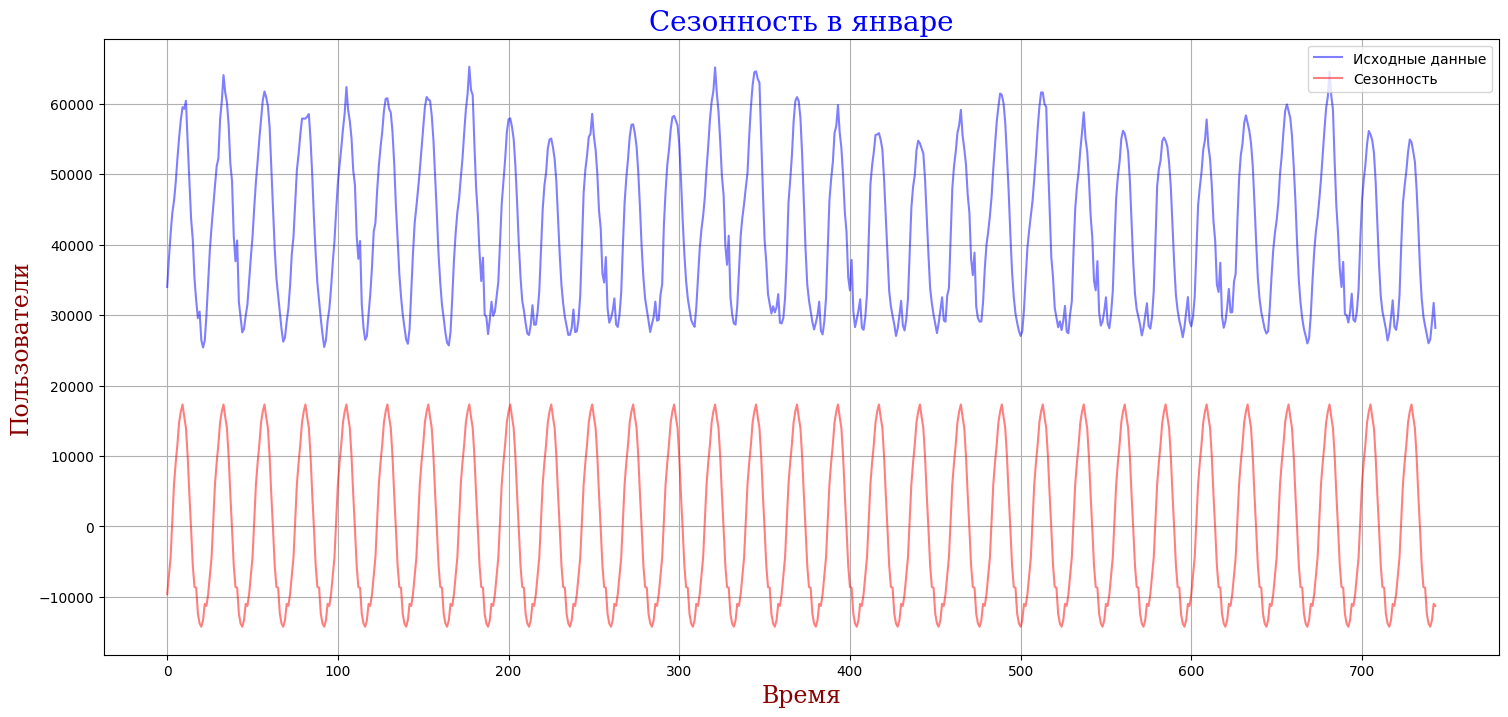

In [185]:
plt.figure(figsize = (18,8))
plt.plot(observed_yanuar, 'b', alpha = 0.5, label='Исходные данные')
plt.plot(seasonal_yanuar, 'r', alpha = 0.5, label='Сезонность')
plt.xlabel('Время',fontdict = font2)
plt.ylabel('Пользователи', fontdict = font2)
plt.title('Сезонность в январе', fontdict = font1)
plt.legend()
plt.grid()
plt.show()

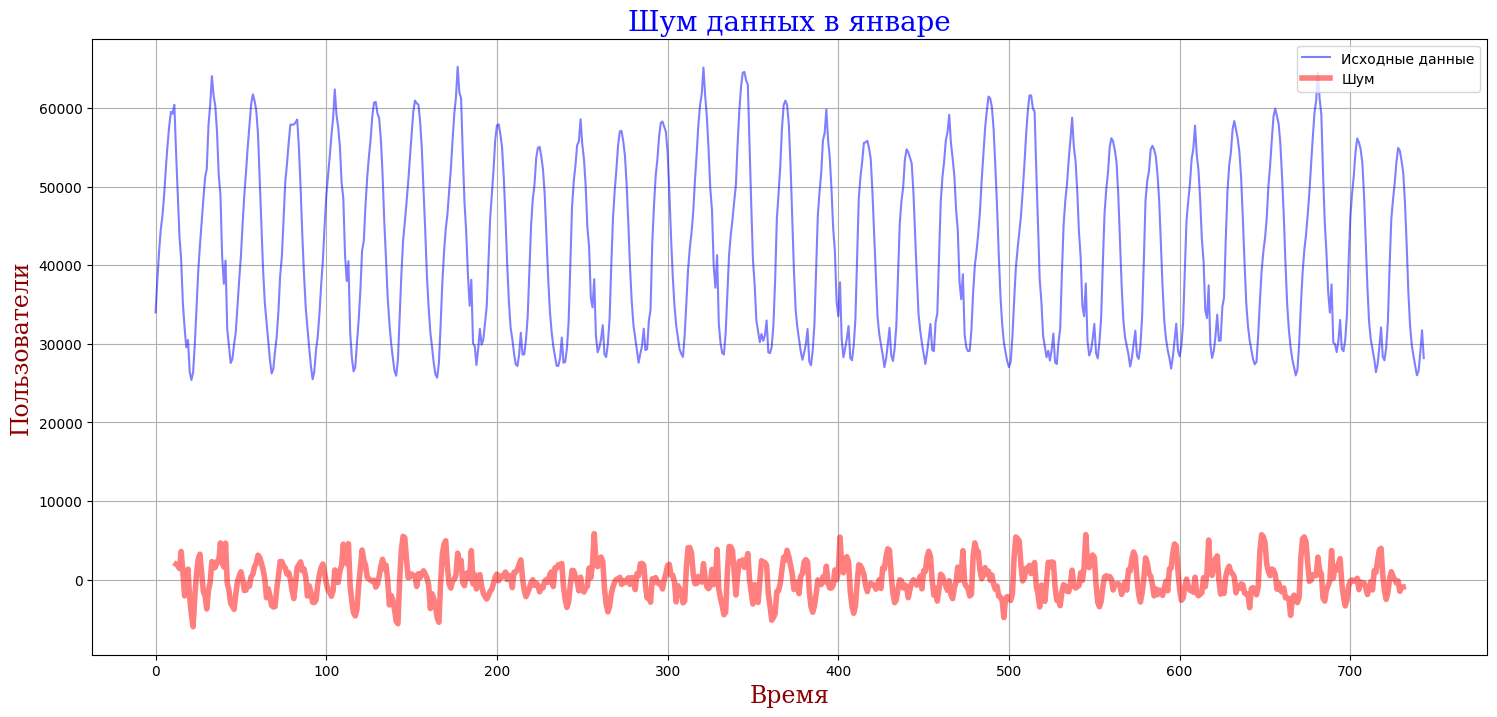

In [186]:
plt.figure(figsize = (18, 8))
plt.plot(observed_yanuar, 'b', alpha = 0.5, label = ('Исходные данные'))
plt.plot(reisid_yanuar, 'r', alpha = 0.5, linewidth = 4, label = ('Шум'))
plt.title('Шум данных в январе', fontdict = font1)
plt.xlabel('Время', fontdict = font2)
plt.ylabel('Пользователи', fontdict = font2)
plt.grid()
plt.legend(loc = 'upper right')
plt.show()

In [187]:
from statsmodels.tsa.stattools import adfuller

In [188]:
result_adfuller_yanuar = adfuller(month_yanuar['Users'])

In [190]:
print('ADF Statistic: %f' % result_adfuller_yanuar[0])
print('p-value: %f' % result_adfuller_yanuar[1])
print('Critical Values:')
for key, value in result_adfuller_yanuar[4].items():
    print('\t%s: %.3f' % (key, value)) 

ADF Statistic: -2.396484
p-value: 0.142731
Critical Values:
	1%: -3.439
	5%: -2.866
	10%: -2.569


In [192]:
# adf чем отрицательнее тем лучше
# p-value должен быть ближе к 0, тут же 0.14 ,больше 0.05 т.е ряд не стационарен

In [219]:
diff_result = month_yanuar.copy()

In [220]:
diff_result['Users'] = diff_result['Users'].diff()

In [222]:
diff_result = diff_result.dropna()

In [223]:
diff_result

,Users,year,month,day,hour
1,3945.0,2017,1,1,1
2,3570.0,2017,1,1,2
3,2959.0,2017,1,1,3
4,1758.0,2017,1,1,4
5,2608.0,2017,1,1,5
...,...,...,...,...,...
739,-1194.0,2017,1,31,19
740,558.0,2017,1,31,20
741,2404.0,2017,1,31,21
742,2781.0,2017,1,31,22


In [224]:
result_adfuller_yanuar_diff = adfuller(diff_result['Users'])

In [225]:
print('ADF Statistic: %f' % result_adfuller_yanuar_diff[0])
print('p-value: %f' % result_adfuller_yanuar_diff[1])
print('Critical Values:')
for key, value in result_adfuller_yanuar_diff[4].items():
    print('\t%s: %.3f' % (key, value)) 

ADF Statistic: -21.447396
p-value: 0.000000
Critical Values:
	1%: -3.439
	5%: -2.866
	10%: -2.569


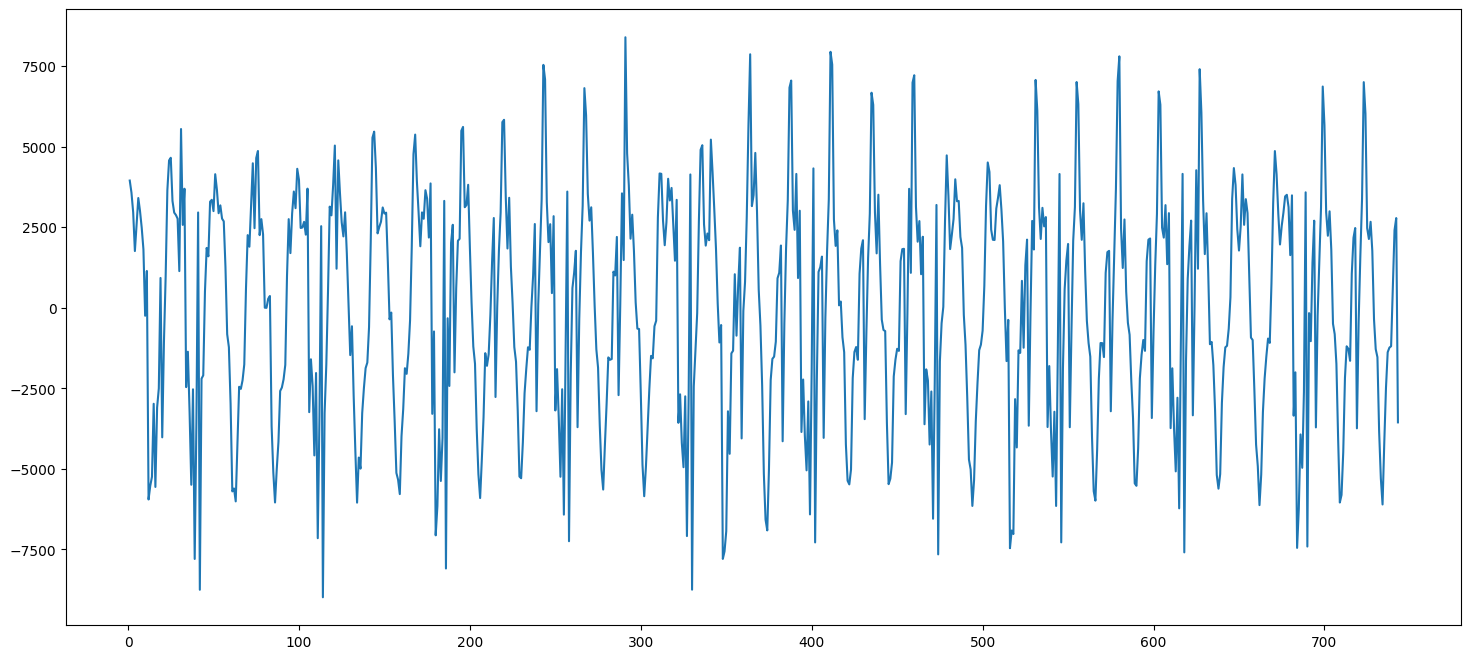

In [231]:
plt.figure(figsize = (18, 8))
diff_result['Users'].plot()
plt.show()

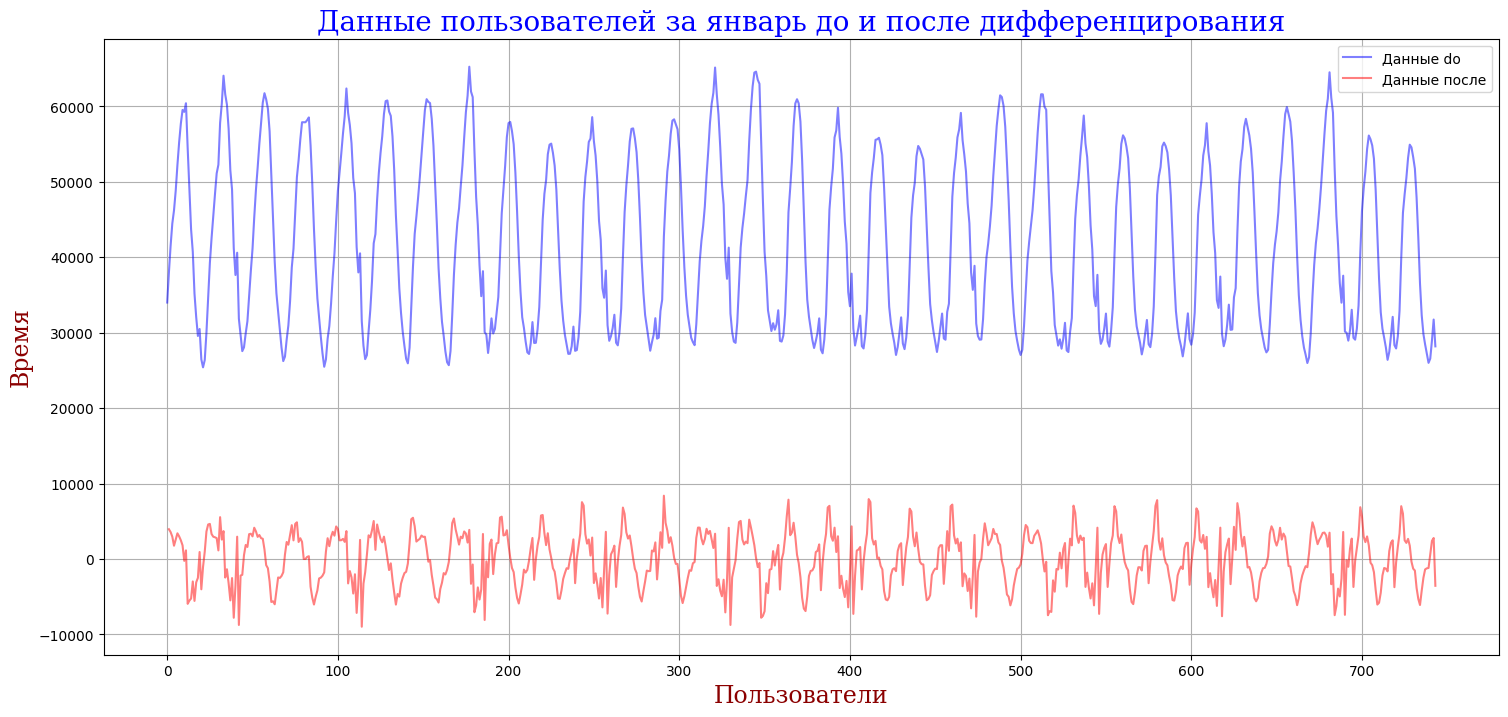

In [235]:
plt.figure(figsize = (18, 8))
plt.plot(month_yanuar['Users'], 'b', alpha = 0.5, label = 'Данные do')
plt.plot(diff_result['Users'], 'r',alpha = 0.5, label = 'Данные после')
plt.title('Данные пользователей за январь до и после дифференцирования', fontdict = font1)
plt.xlabel('Пользователи', fontdict = font2)
plt.ylabel('Время', fontdict = font2)
plt.legend(loc = 'upper right')
plt.grid(True)
plt.show()

In [271]:
proba_predict_df = diff_result.copy() 

In [269]:
y.shape

(742,)

In [272]:
proba_predict_df['lag1'] = proba_predict_df['Users'].shift(1)
proba_predict_df['lag2'] = proba_predict_df['Users'].shift(2)
proba_predict_df['lag3'] = proba_predict_df['Users'].shift(3)

In [273]:
proba_predict_df['target'] = proba_predict_df['Users'].shift(-1)

In [274]:
proba_predict_df = proba_predict_df.dropna() 

In [275]:
proba_predict_df

,Users,year,month,day,hour,lag1,lag2,lag3,target
4,1758.0,2017,1,1,4,2959.0,3570.0,3945.0,2608.0
5,2608.0,2017,1,1,5,1758.0,2959.0,3570.0,3403.0
6,3403.0,2017,1,1,6,2608.0,1758.0,2959.0,3000.0
7,3000.0,2017,1,1,7,3403.0,2608.0,1758.0,2480.0
8,2480.0,2017,1,1,8,3000.0,3403.0,2608.0,1809.0
...,...,...,...,...,...,...,...,...,...
738,-1239.0,2017,1,31,18,-1381.0,-2488.0,-4200.0,-1194.0
739,-1194.0,2017,1,31,19,-1239.0,-1381.0,-2488.0,558.0
740,558.0,2017,1,31,20,-1194.0,-1239.0,-1381.0,2404.0
741,2404.0,2017,1,31,21,558.0,-1194.0,-1239.0,2781.0


In [276]:
proba_predict_df.columns

Index(['Users', 'year', 'month', 'day', 'hour', 'lag1', 'lag2', 'lag3',
       'target'],
      dtype='object')

In [277]:
x = proba_predict_df.drop(columns = ['Users', 'target'])

In [278]:
y = proba_predict_df['target']

In [299]:
pri = int(len(x) * 0.8)

In [301]:
x_train = x[ : pri]
x_test = x[pri : ]
y_train = y[ : pri]
y_test = y[pri : ]

In [302]:
print(x_train.shape) 
print(x_test.shape)  
print(y_train.shape)  
print(y_test.shape) 

(591, 7)
(148, 7)
(591,)
(148,)


In [317]:
import keras
from keras.layers import Flatten, Dense
from keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras import regularizers


In [516]:
stopping_ = keras.callbacks.EarlyStopping(
            monitor="val_mae",
            min_delta=0,
            patience=15,
            verbose=1,
            baseline=None,
            restore_best_weights=True,
            start_from_epoch=0
            )

In [554]:
model = keras.Sequential([
    keras.layers.Input(shape=(x_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

In [329]:
history = model.fit(x_train, y_train, epochs = 100, batch_size = 16, 
                    verbose = 1, validation_split = 0.1, callbacks = [stopping_])

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 8376444.5000 - mae: 2321.1521 - val_loss: 9730544.0000 - val_mae: 2639.7488
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8121538.0000 - mae: 2273.4705 - val_loss: 8686436.0000 - val_mae: 2429.1501
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7711833.5000 - mae: 2245.6494 - val_loss: 8128313.5000 - val_mae: 2341.2068
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7585795.0000 - mae: 2215.1885 - val_loss: 8169348.5000 - val_mae: 2324.9089
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6982390.5000 - mae: 2101.9631 - val_loss: 7991805.5000 - val_mae: 2296.1392
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6830549.0000 - mae: 2088.1853 - val_loss: 7484531.5000 - val_mae: 2209.3267
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6565622.5000 - mae: 2052.5098 - val_loss: 7374228.5000 - val_mae: 2180.4900
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

In [304]:
predict = model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


In [341]:
tes = proba_predict_df['target'][pri:]

In [450]:
from sklearn.metrics import mean_absolute_error , r2_score

In [349]:
mae_test

1312.5689724071606

In [345]:
tes = tes.reset_index(drop = True)

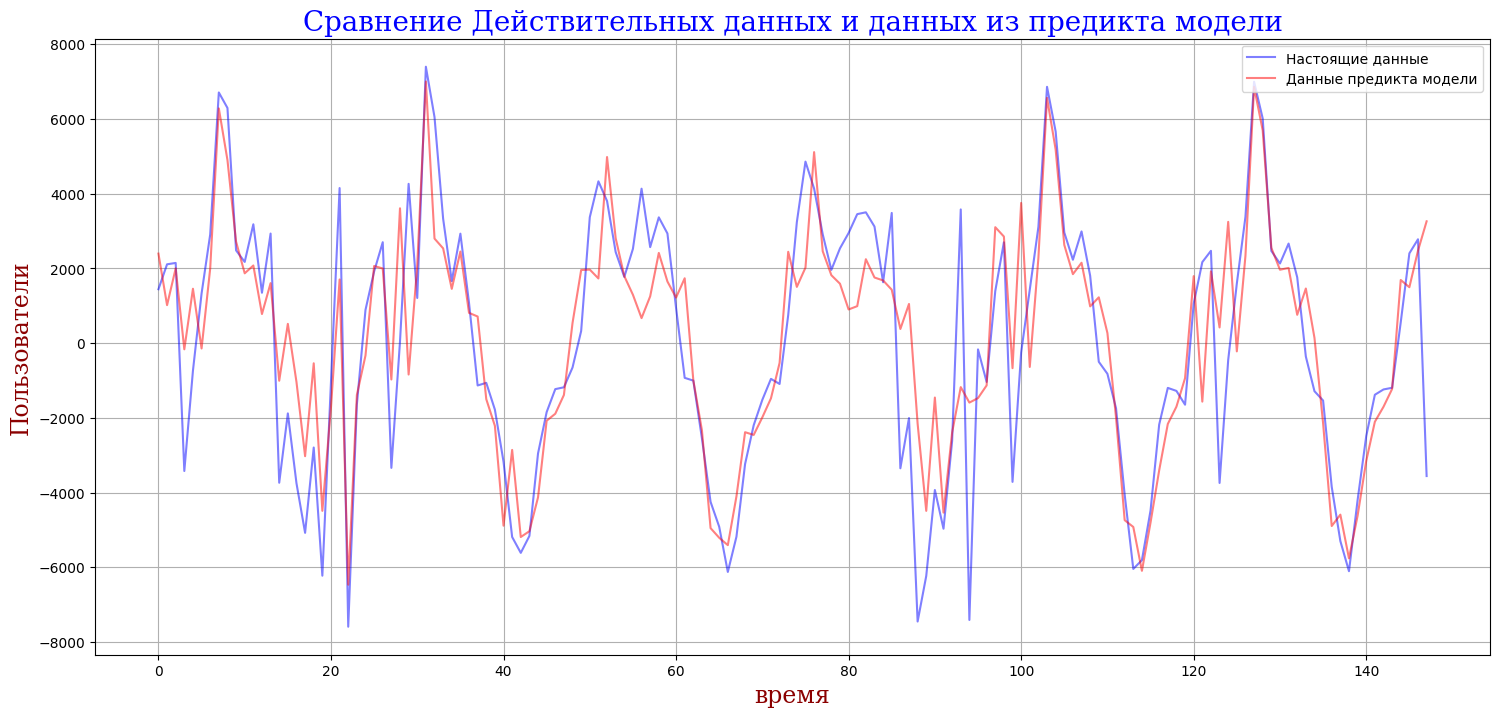

In [346]:
plt.figure(figsize = (18,8))
plt.plot(tes, 'b', alpha = 0.5, label = 'Настоящие данные')
plt.plot(predict, 'r', alpha = 0.5, label = 'Данные предикта модели')
plt.title('Сравнение Действительных данных и данных из предикта модели',fontdict = font1)
plt.xlabel('время', fontdict = font2)
plt.ylabel('Пользователи', fontdict = font2)
plt.legend(loc = 'upper right')
plt.grid(True)
plt.show()

In [456]:
df = df_new.copy()

In [458]:
df['Time'] = pd.to_datetime(df['Time'])

In [460]:
df['year'] = df['Time'].dt.year
df['month'] = df['Time'].dt.month
df['day'] = df['Time'].dt.day
df['hour'] = df['Time'].dt.hour


In [461]:
df['lag1'] = df['Users'].shift(1)
df['lag2'] = df['Users'].shift(2)
df['lag3'] = df['Users'].shift(3)

In [462]:
df['lag6'] = df['Users'].shift(6)
df['lag12'] = df['Users'].shift(12)
df['lag24'] = df['Users'].shift(24)

In [463]:
df['mean_3h'] = df['Users'].rolling(6).mean()      
df['mean_6h'] = df['Users'].rolling(12).mean()      
df['mean_24h'] = df['Users'].rolling(24).mean()    
df['std_6h'] = df['Users'].rolling(12).std()        
df['max_12h'] = df['Users'].rolling(12).max()      
df['min_12h'] = df['Users'].rolling(12).min() 

In [464]:
adful = adfuller(df['Users'])

In [465]:
print('ADF Statistic: %f' % adful[0])
print('p-value: %f' % adful[1])
print('Critical Values:')
for key, value in adful[4].items():
    print('\t%s: %.3f' % (key, value)) 

ADF Statistic: -2.245379
p-value: 0.190189
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567


In [473]:
df_diff = df.copy()

In [475]:
df_diff['target'] = df_diff['Users'].shift(-1)

In [521]:
df_diff = df_diff.dropna()
df_diff['users_diff'] = df_diff['Users'].diff()

In [522]:
df_diff.columns

Index(['Time', 'Users', 'year', 'month', 'day', 'hour', 'lag1', 'lag2', 'lag3',
       'lag6', 'lag12', 'lag24', 'mean_3h', 'mean_6h', 'mean_24h', 'std_6h',
       'max_12h', 'min_12h', 'target', 'users_diff'],
      dtype='object')

In [545]:
df_diff = df_diff.dropna()

In [546]:
columnss = ['year', 'month', 'day', 'hour', 'lag1', 'lag2', 'lag3',
       'lag6', 'lag12', 'lag24', 'mean_3h', 'mean_6h', 'mean_24h', 'std_6h',
       'max_12h', 'min_12h','users_diff']

In [547]:
x = df_diff[columnss]
y = df_diff['target']

In [548]:
splt = int(len(x) * 0.8 )

In [549]:
x_train = x[ : splt]
x_test = x[splt : ]
y_train = y[: splt]
y_test = y[splt : ]

In [550]:
print(x_train.shape) 
print(x_test.shape)  
print(y_train.shape)  
print(y_test.shape) 

(2079, 17)
(520, 17)
(2079,)
(520,)


In [555]:
history2 = model.fit(x_train, y_train, epochs = 100, batch_size = 32, 
                    verbose = 1, validation_split = 0.1, callbacks = [stopping_])

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 309543520.0000 - mae: 12783.9482 - val_loss: 32695434.0000 - val_mae: 4747.8306
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 73702720.0000 - mae: 6691.9673 - val_loss: 42629272.0000 - val_mae: 6038.7900
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51619476.0000 - mae: 5497.7803 - val_loss: 32189988.0000 - val_mae: 5098.5645
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45437140.0000 - mae: 5088.9951 - val_loss: 46073880.0000 - val_mae: 6359.2354
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38043864.0000 - mae: 4740.8667 - val_loss: 49820844.0000 - val_mae: 6576.1177
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35467676.0000 - mae: 4511.4448 - val_loss: 33314962.0000 - val_mae: 5378.1021
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33970556.0000 - mae: 4386.6006 - val_loss: 48512848.0000 - val_mae: 6593.3169
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━

In [556]:
predicts = model.predict(x_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [557]:
mae_tests = mean_absolute_error(predicts, y_test)
mae_tests

5067.205742938702

In [558]:
test = y_test.reset_index(drop = True)

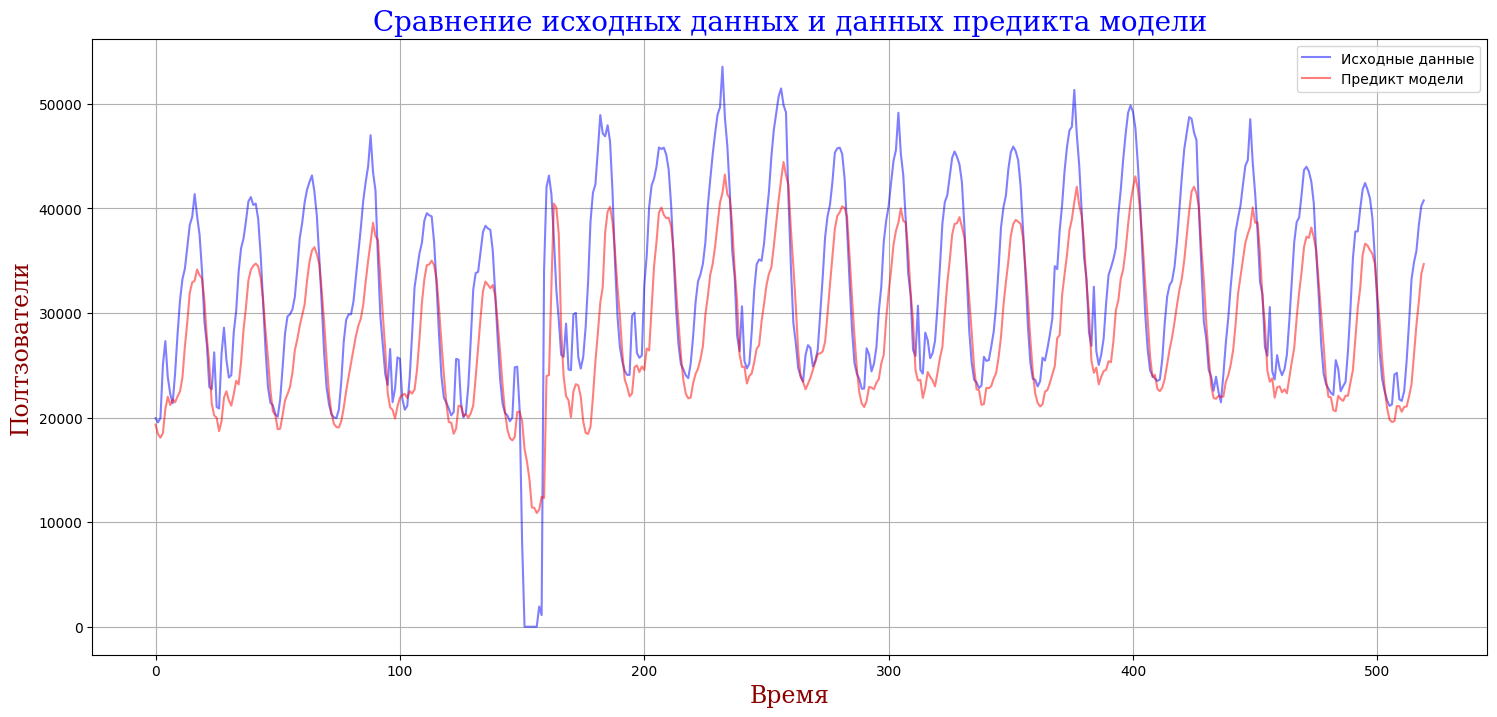

In [561]:
plt.figure(figsize = (18, 8))
plt.plot(test, 'b', alpha = .5, label = 'Исходные данные')
plt.plot(predicts, 'r', alpha = .5, label = 'Предикт модели')
plt.title('Сравнение исходных данных и данных предикта модели', fontdict = font1)
plt.xlabel('Время', fontdict = font2)
plt.ylabel('Полтзователи', fontdict = font2)
plt.grid()
plt.legend(loc = 'upper right')
plt.show()

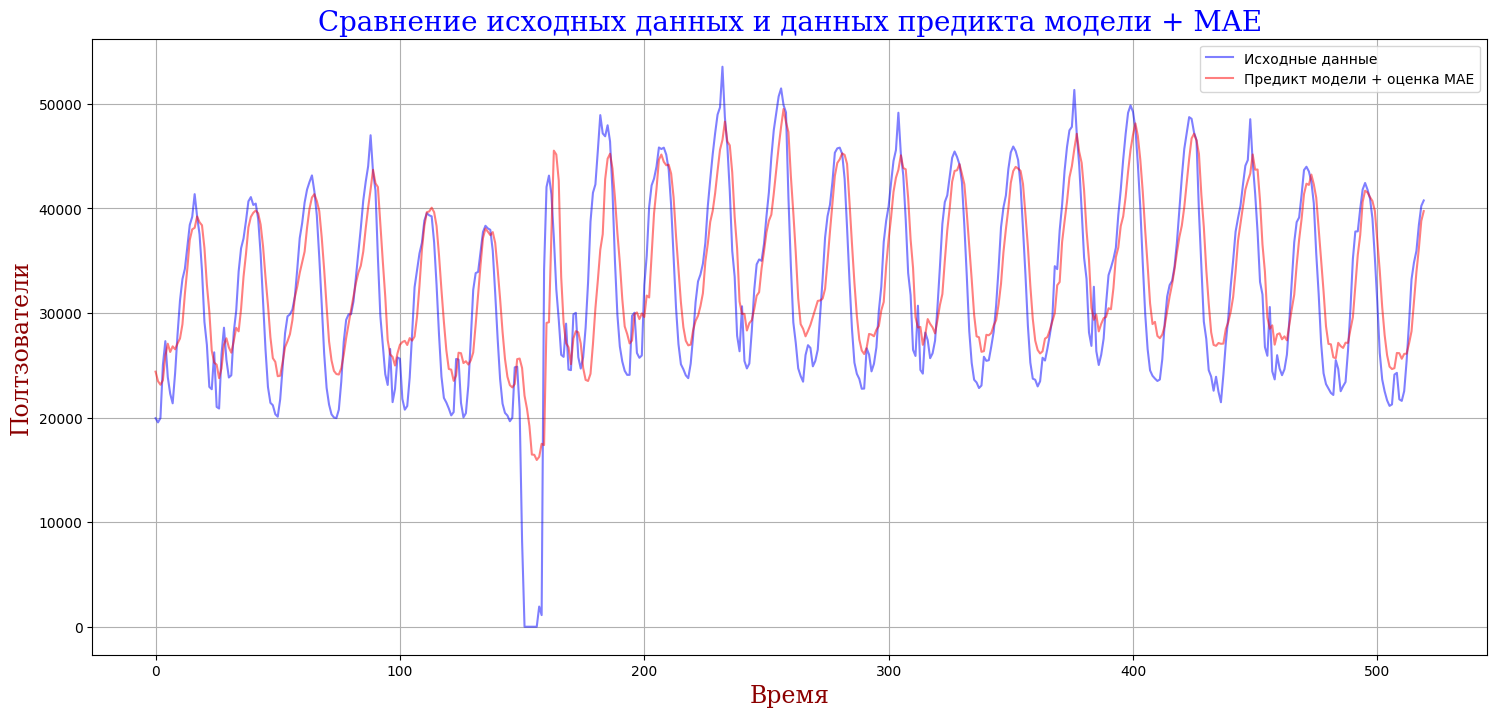

In [563]:
plt.figure(figsize = (18, 8))
plt.plot(test, 'b', alpha = .5, label = 'Исходные данные')
plt.plot(predicts + mae_tests, 'r', alpha = .5, label = 'Предикт модели + оценка MAE')
plt.title('Сравнение исходных данных и данных предикта модели + MAE', fontdict = font1)
plt.xlabel('Время', fontdict = font2)
plt.ylabel('Полтзователи', fontdict = font2)
plt.grid()
plt.legend(loc = 'upper right')
plt.show()

In [576]:
predict_hour = model.predict([x[columnss].iloc[:-1]])[0]

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [596]:
predict_hour

array([30712.648], dtype=float32)